# NB_TEMPLATE

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thinkthoughts/sensors-becker/blob/main/templates/NB_TEMPLATE.ipynb)

This first-class repository artifact compiles one Reading Point YAML specification into a complete notebook artifact bundle.

Only the template configuration and Reading Point YAML change. Runtime initialization, rendering, records, verification, and packaging remain shared.


In [1]:
TEMPLATE_ID = "NB_TEMPLATE"
TEMPLATE_VERSION = "2.0.1"

# Repository-relative path used where this notebook runs inside sensors-becker.
SPEC_PATH = "templates/RP_TEMPLATE.yaml"

# Optional override for testing another specification without editing mechanics.
SPEC_PATH_OVERRIDE = None

{
    "template_id": TEMPLATE_ID,
    "template_version": TEMPLATE_VERSION,
    "spec_path": SPEC_PATH_OVERRIDE or SPEC_PATH,
    "architecture": "package-dialogue-renderer",
}


{'template_id': 'NB_TEMPLATE',
 'template_version': '2.0.0',
 'spec_path': 'templates/RP_TEMPLATE.yaml',
 'architecture': 'package-dialogue-renderer'}

## Initialize Repository Runtime

The template initializes the repository once and resolves the Reading Point specification and renderer from repository paths.


In [2]:
from __future__ import annotations

import importlib
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = "https://github.com/thinkthoughts/sensors-becker.git"
COLAB_REPOSITORY_ROOT = Path("/content/sensors-becker")


def install_colab_repository() -> Path:
    if COLAB_REPOSITORY_ROOT.exists():
        shutil.rmtree(COLAB_REPOSITORY_ROOT)

    subprocess.run(
        ["git", "clone", "--depth", "1", REPOSITORY_URL, str(COLAB_REPOSITORY_ROOT)],
        check=True,
    )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--editable",
            str(COLAB_REPOSITORY_ROOT),
        ],
        check=True,
    )

    src_directory = COLAB_REPOSITORY_ROOT / "src"
    if str(src_directory) not in sys.path:
        sys.path.insert(0, str(src_directory))

    importlib.invalidate_caches()
    os.chdir(COLAB_REPOSITORY_ROOT)
    return COLAB_REPOSITORY_ROOT


try:
    import sensors_becker
except ModuleNotFoundError:
    repository_root = install_colab_repository()
    import sensors_becker
else:
    repository_root = Path(sensors_becker.__file__).resolve().parents[2]

from sensors_becker import initialize_notebook

runtime = initialize_notebook(
    start=repository_root,
    environment=(
        "google-colab"
        if repository_root == COLAB_REPOSITORY_ROOT
        else "repository-runtime"
    ),
)
context = runtime.context
runtime.validate()

spec_path = Path(SPEC_PATH_OVERRIDE or SPEC_PATH)
if not spec_path.is_absolute():
    spec_path = repository_root / spec_path

if not spec_path.exists():
    raise FileNotFoundError(
        f"Reading Point specification not found: {spec_path}"
    )

print(f"Environment: {runtime.environment}")
print(f"Repository root: {runtime.repository_root}")
print(f"Specification: {runtime.relative_path(spec_path)}")
print("Engineering context validation: PASSED")


Environment: google-colab
Repository root: /content/sensors-becker
Specification: templates/RP_TEMPLATE.yaml
Engineering context validation: PASSED


## Load Reading Point Specification

The YAML file is the editable engineering source. This cell normalizes and validates it before any artifacts are generated.


In [3]:
from dataclasses import dataclass
from typing import Any

try:
    import yaml
except ModuleNotFoundError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "pyyaml"],
        check=True,
    )
    import yaml


@dataclass(frozen=True)
class DialogueArtifactSpec:
    order: str
    artifact_id: str
    concept: str
    title: str
    first_label: str
    second_label: str
    supporting_context: tuple[str, str]
    engineering_statement: str
    status: str


def required(mapping: dict[str, Any], key: str, context_name: str) -> Any:
    value = mapping.get(key)
    if value in (None, "", (), []):
        raise ValueError(f"{context_name}.{key} is required")
    return value


raw_spec = yaml.safe_load(spec_path.read_text(encoding="utf-8"))
if not isinstance(raw_spec, dict):
    raise TypeError("RP_TEMPLATE.yaml must contain one top-level mapping")

identity = required(raw_spec, "identity", "specification")
reading_point = required(raw_spec, "reading_point", "specification")
dialogue_source = required(raw_spec, "dialogue", "specification")

notebook_id = required(identity, "notebook_id", "identity")
reading_point_id = (
    identity.get("reading_point")
    or identity.get("reading_point_id")
    or reading_point.get("reading_point_id")
)
if not reading_point_id:
    raise ValueError("A reading_point identifier is required")

stage = required(identity, "stage", "identity")
version = str(identity.get("version", "0.1.0"))
status = str(identity.get("status", "candidate"))

engineering_objective = required(
    reading_point,
    "engineering_objective",
    "reading_point",
)
natural_foundation = required(
    reading_point,
    "natural_foundation",
    "reading_point",
)
if isinstance(natural_foundation, list):
    natural_foundation = natural_foundation[0]

engineering_statements = tuple(
    required(reading_point, "engineering_statements", "reading_point")
)
repository_grammar = tuple(reading_point.get("repository_grammar", ()))
forward_context = reading_point.get("forward_context", "")
inherited_from = reading_point.get("inherited_from", "")
completion_status = reading_point.get("status", "developing")

engineering_object = raw_spec.get("engineering_object", "Microcalorimeter")
engineering_direction = raw_spec.get(
    "engineering_direction",
    "Toward next-generation microcalorimeters.",
)
footer = raw_spec.get(
    "footer",
    "Admissible generalizations trail leading specifications.",
)

dialogue_specs = []
for item in dialogue_source:
    order = str(required(item, "order", "dialogue item"))
    first_label = required(item, "first_label", f"dialogue {order}")
    second_label = required(item, "second_label", f"dialogue {order}")
    statement = required(
        item,
        "engineering_statement",
        f"dialogue {order}",
    )
    support = tuple(
        required(item, "supporting_context", f"dialogue {order}")
    )
    if len(support) != 2:
        raise ValueError(
            f"dialogue {order}.supporting_context must contain two labels"
        )

    concept = item.get("concept", second_label)
    artifact_id = item.get(
        "artifact_id",
        f"{reading_point_id.replace('RP_', '')}_{order}_{str(concept).lower().replace(' ', '_')}_trail",
    )
    title = item.get(
        "title",
        f"{concept} Trail: {engineering_object}s"
        if not str(engineering_object).endswith("s")
        else f"{concept} Trail: {engineering_object}",
    )

    dialogue_specs.append(
        DialogueArtifactSpec(
            order=order,
            artifact_id=artifact_id,
            concept=str(concept),
            title=str(title),
            first_label=str(first_label),
            second_label=str(second_label),
            supporting_context=(str(support[0]), str(support[1])),
            engineering_statement=str(statement),
            status=str(item.get("status", status)),
        )
    )

NOTEBOOK_SPEC = {
    "template_id": TEMPLATE_ID,
    "template_version": TEMPLATE_VERSION,
    "notebook_id": notebook_id,
    "notebook_filename": f"{notebook_id}.ipynb",
    "notebook_version": version,
    "reading_point_id": reading_point_id,
    "engineering_stage": stage,
    "status": status,
    "natural_foundation": natural_foundation,
    "engineering_objective": engineering_objective,
    "engineering_statements": engineering_statements,
    "repository_grammar": repository_grammar,
    "forward_context": forward_context,
    "inherited_from": inherited_from,
    "completion_status": completion_status,
    "engineering_object": engineering_object,
    "engineering_direction": engineering_direction,
    "footer": footer,
    "dialogue": tuple(dialogue_specs),
    "release_filename": f"{notebook_id}.zip",
}

assert NOTEBOOK_SPEC["dialogue"]
assert tuple(item.order for item in NOTEBOOK_SPEC["dialogue"]) == tuple(
    sorted(item.order for item in NOTEBOOK_SPEC["dialogue"])
)
assert all(
    item.engineering_statement in NOTEBOOK_SPEC["engineering_statements"]
    for item in NOTEBOOK_SPEC["dialogue"]
)

NOTEBOOK_SPEC


{'template_id': 'NB_TEMPLATE',
 'template_version': '2.0.0',
 'notebook_id': 'NB_29_C_MEASURED_ENGINEERING_IMPROVEMENT',
 'notebook_filename': 'NB_29_C_MEASURED_ENGINEERING_IMPROVEMENT.ipynb',
 'notebook_version': '1.1.0',
 'reading_point_id': 'RP_29',
 'engineering_stage': 'C',
 'status': 'candidate',
 'natural_foundation': 'Engineering Refinements',
 'engineering_objective': 'Support Measured Engineering Improvement.',
 'engineering_statements': ('Measured Engineering States identify Engineering Constraints.',
  'Engineering Constraints direct Engineering Refinements.',
  'Engineering Refinements support Measured Engineering Improvement.'),
 'repository_grammar': ('Engineering Object specifies Engineering System.',
  'Engineering System produces Measured Engineering States.',
  'Measurement records Measured Engineering States.',
  'Measured Engineering States identify Engineering Constraints.',
  'Engineering Constraints direct Engineering Refinements.',
  'Engineering Refinements su

## Initialize Package Renderer

The template imports the reusable dialogue specification and renderer from `src/sensors_becker`. The legacy renderer in `templates/` remains untouched during verification but is no longer loaded by this notebook.


In [4]:
import json
import zipfile
from datetime import date
from hashlib import sha256

from IPython.display import Image, Markdown, display

from sensors_becker.dialogue_renderer import DialogueRenderer
from sensors_becker.dialogue_specification import (
    DialogueNode,
    DialogueRelation,
    DialogueSpecification,
)


renderer = DialogueRenderer(
    figsize=(12, 8),
    dpi=180,
    validate_layout=True,
)


def sha256_for_path(path: Path) -> str:
    digest = sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def display_artifact(path: Path) -> None:
    if path.suffix.lower() == ".png":
        display(Image(filename=str(path)))
    elif path.suffix.lower() == ".md":
        display(Markdown(path.read_text(encoding="utf-8")))
    else:
        print(path.read_text(encoding="utf-8"))
    print(f"Artifact: {path.name}")


def build_dialogue_specification(
    spec: DialogueArtifactSpec,
) -> DialogueSpecification:
    return DialogueSpecification(
        title=spec.title,
        subtitle=NOTEBOOK_SPEC["engineering_direction"],
        footer=NOTEBOOK_SPEC["footer"],
        primary_nodes=(
            DialogueNode(
                label=spec.first_label,
                x=0.5,
                y=0.67,
                width=0.42,
                height=0.10,
                role="input",
                fontsize=18,
            ),
            DialogueNode(
                label=spec.second_label,
                x=0.5,
                y=0.46,
                width=0.42,
                height=0.12,
                role="primary",
                emphasis=True,
                fontsize=21,
            ),
        ),
        primary_relations=(
            DialogueRelation(
                start=(0.5, 0.62),
                end=(0.5, 0.52),
                role="input",
                directional=True,
                linewidth=2.0,
            ),
        ),
        supporting_context=spec.supporting_context,
    )


def build_alt_text(spec: DialogueArtifactSpec) -> str:
    left, right = spec.supporting_context
    return (
        "# Alt Text\n\n"
        f"**{spec.title}.** Diagram showing {spec.first_label.lower()} "
        f"leading to {spec.second_label.lower()}. "
        f"{left} and {right} appear as supporting engineering dialogue. "
        f"The engineering statement is: “{spec.engineering_statement}” "
        f"Subtitle: “{NOTEBOOK_SPEC['engineering_direction']}” "
        f"Footer: “{NOTEBOOK_SPEC['footer']}”\n"
    )


bundle_directory = (
    runtime.paths.outputs
    / "releases"
    / NOTEBOOK_SPEC["notebook_id"]
)
bundle_directory.mkdir(parents=True, exist_ok=True)

for prior_path in bundle_directory.iterdir():
    if prior_path.is_file():
        prior_path.unlink()

print(f"Renderer: {renderer.__class__.__name__}")
print("Architecture: package-dialogue-renderer")
print(f"Reading Point: {NOTEBOOK_SPEC['reading_point_id']}")
print(f"Artifact specifications: {len(NOTEBOOK_SPEC['dialogue'])}")
print(f"Bundle directory: {runtime.relative_path(bundle_directory)}")


Renderer: DialogueRenderer
Architecture: package-dialogue-renderer
Reading Point: RP_29
Artifact specifications: 3
Bundle directory: outputs/releases/NB_29_C_MEASURED_ENGINEERING_IMPROVEMENT


## Generate Dialogue Artifacts

Every dialogue entry in the YAML specification produces one PNG and one alt-text artifact.


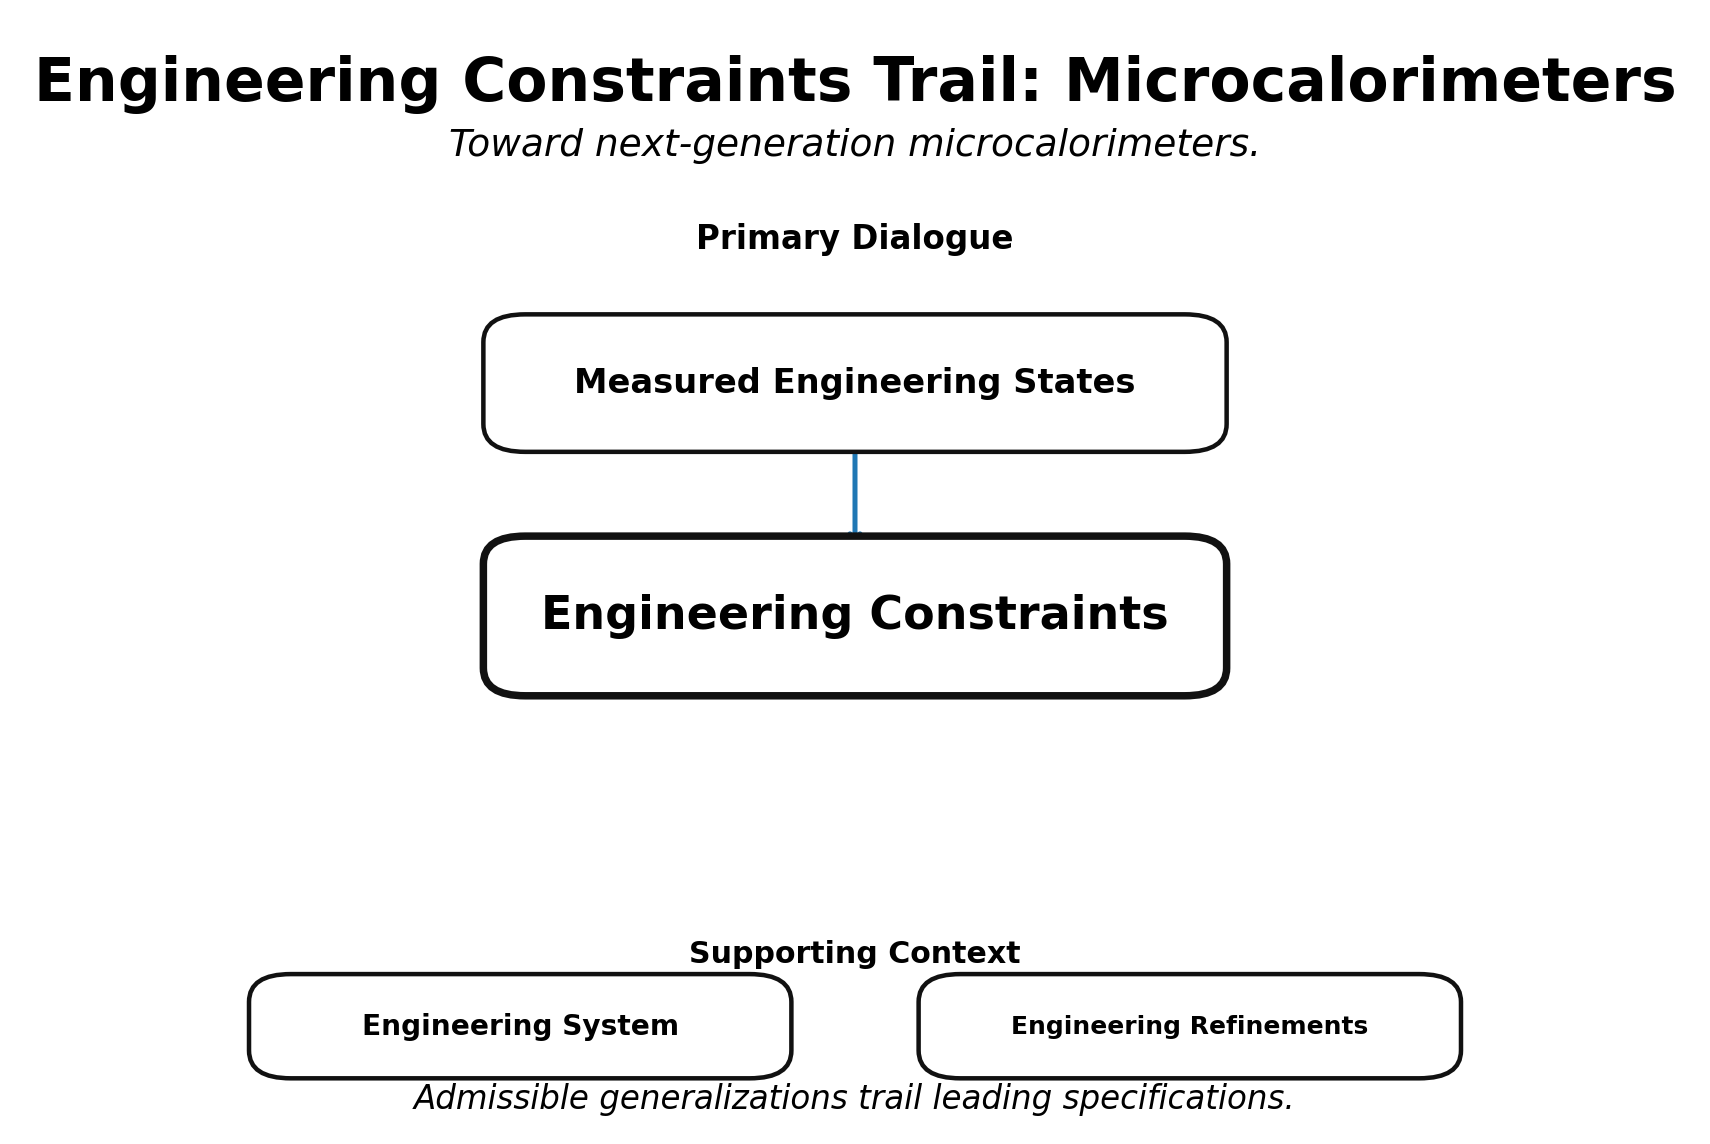

Artifact: 29_A_engineering_constraints_trail.png


# Alt Text

**Engineering Constraints Trail: Microcalorimeters.** Diagram showing measured engineering states leading to engineering constraints. Engineering System and Engineering Refinements appear as supporting engineering dialogue. The engineering statement is: “Measured Engineering States identify Engineering Constraints.” Subtitle: “Toward next-generation microcalorimeters.” Footer: “Admissible generalizations trail leading specifications.”


Artifact: 29_A_engineering_constraints_trail.alt.md


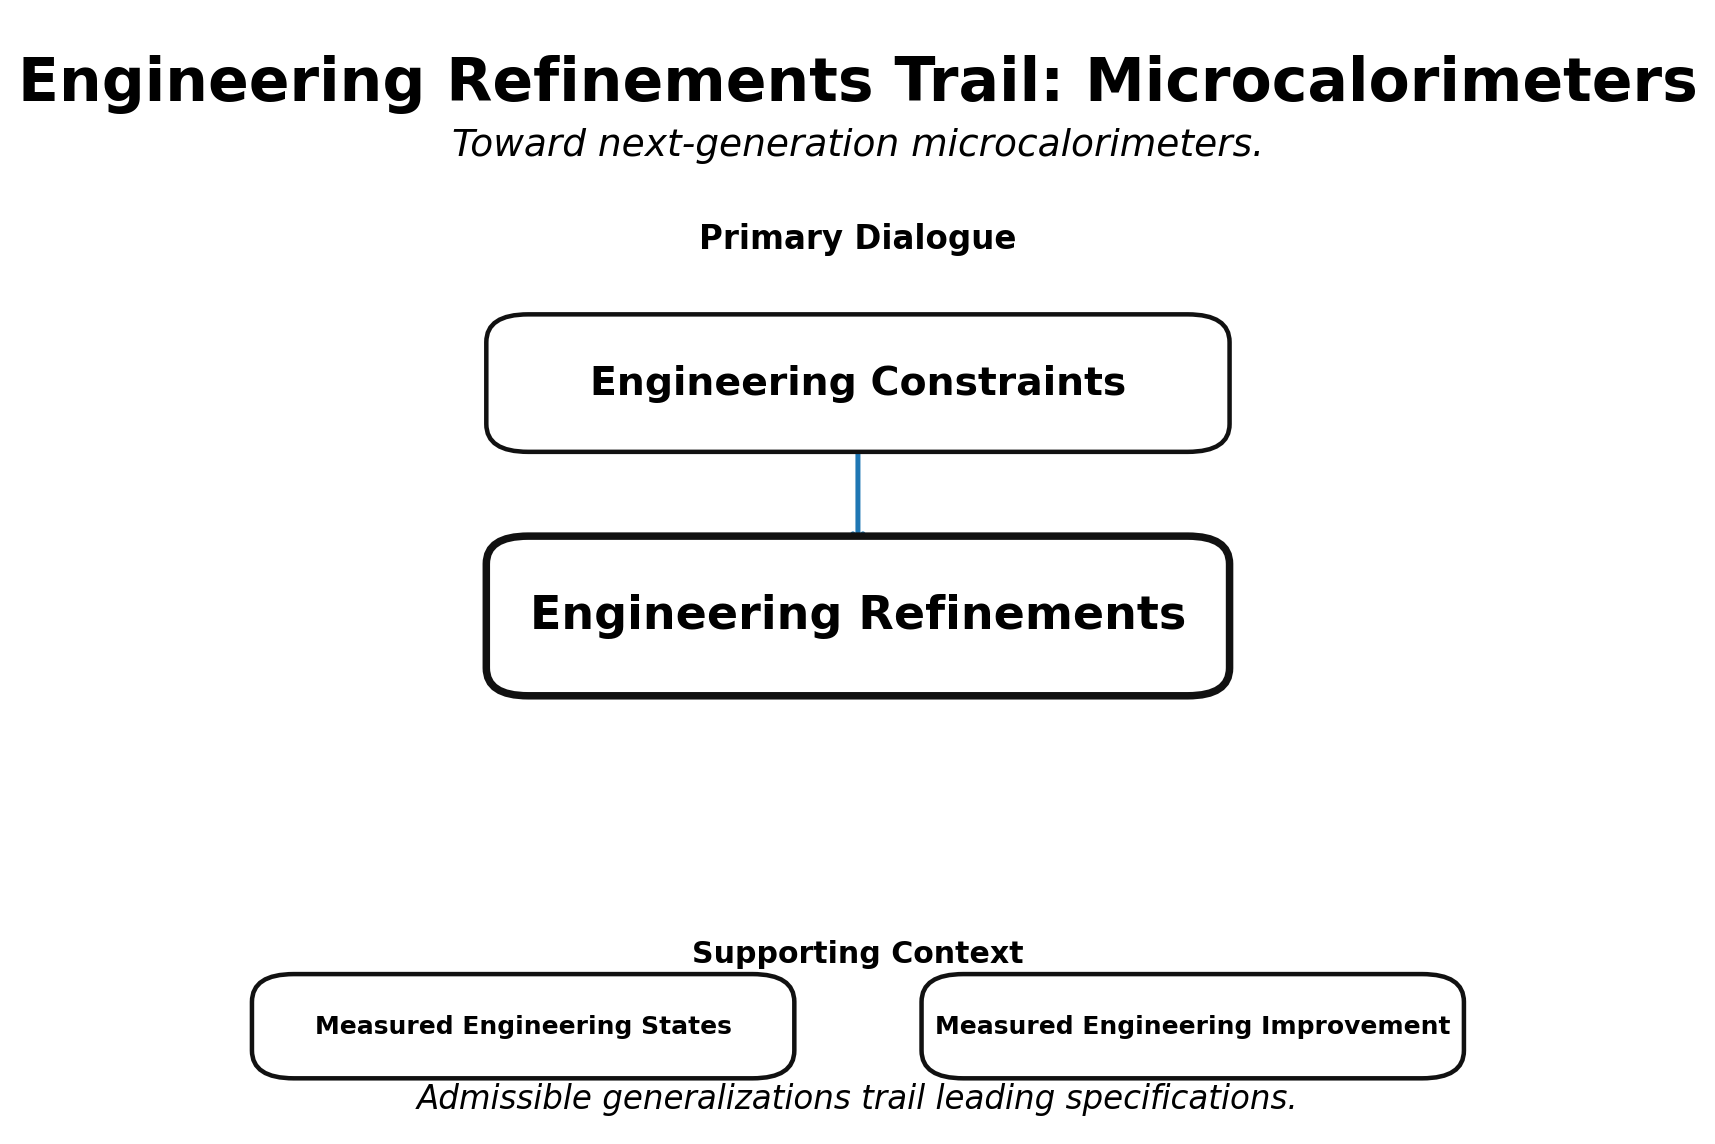

Artifact: 29_B_engineering_refinements_trail.png


# Alt Text

**Engineering Refinements Trail: Microcalorimeters.** Diagram showing engineering constraints leading to engineering refinements. Measured Engineering States and Measured Engineering Improvement appear as supporting engineering dialogue. The engineering statement is: “Engineering Constraints direct Engineering Refinements.” Subtitle: “Toward next-generation microcalorimeters.” Footer: “Admissible generalizations trail leading specifications.”


Artifact: 29_B_engineering_refinements_trail.alt.md


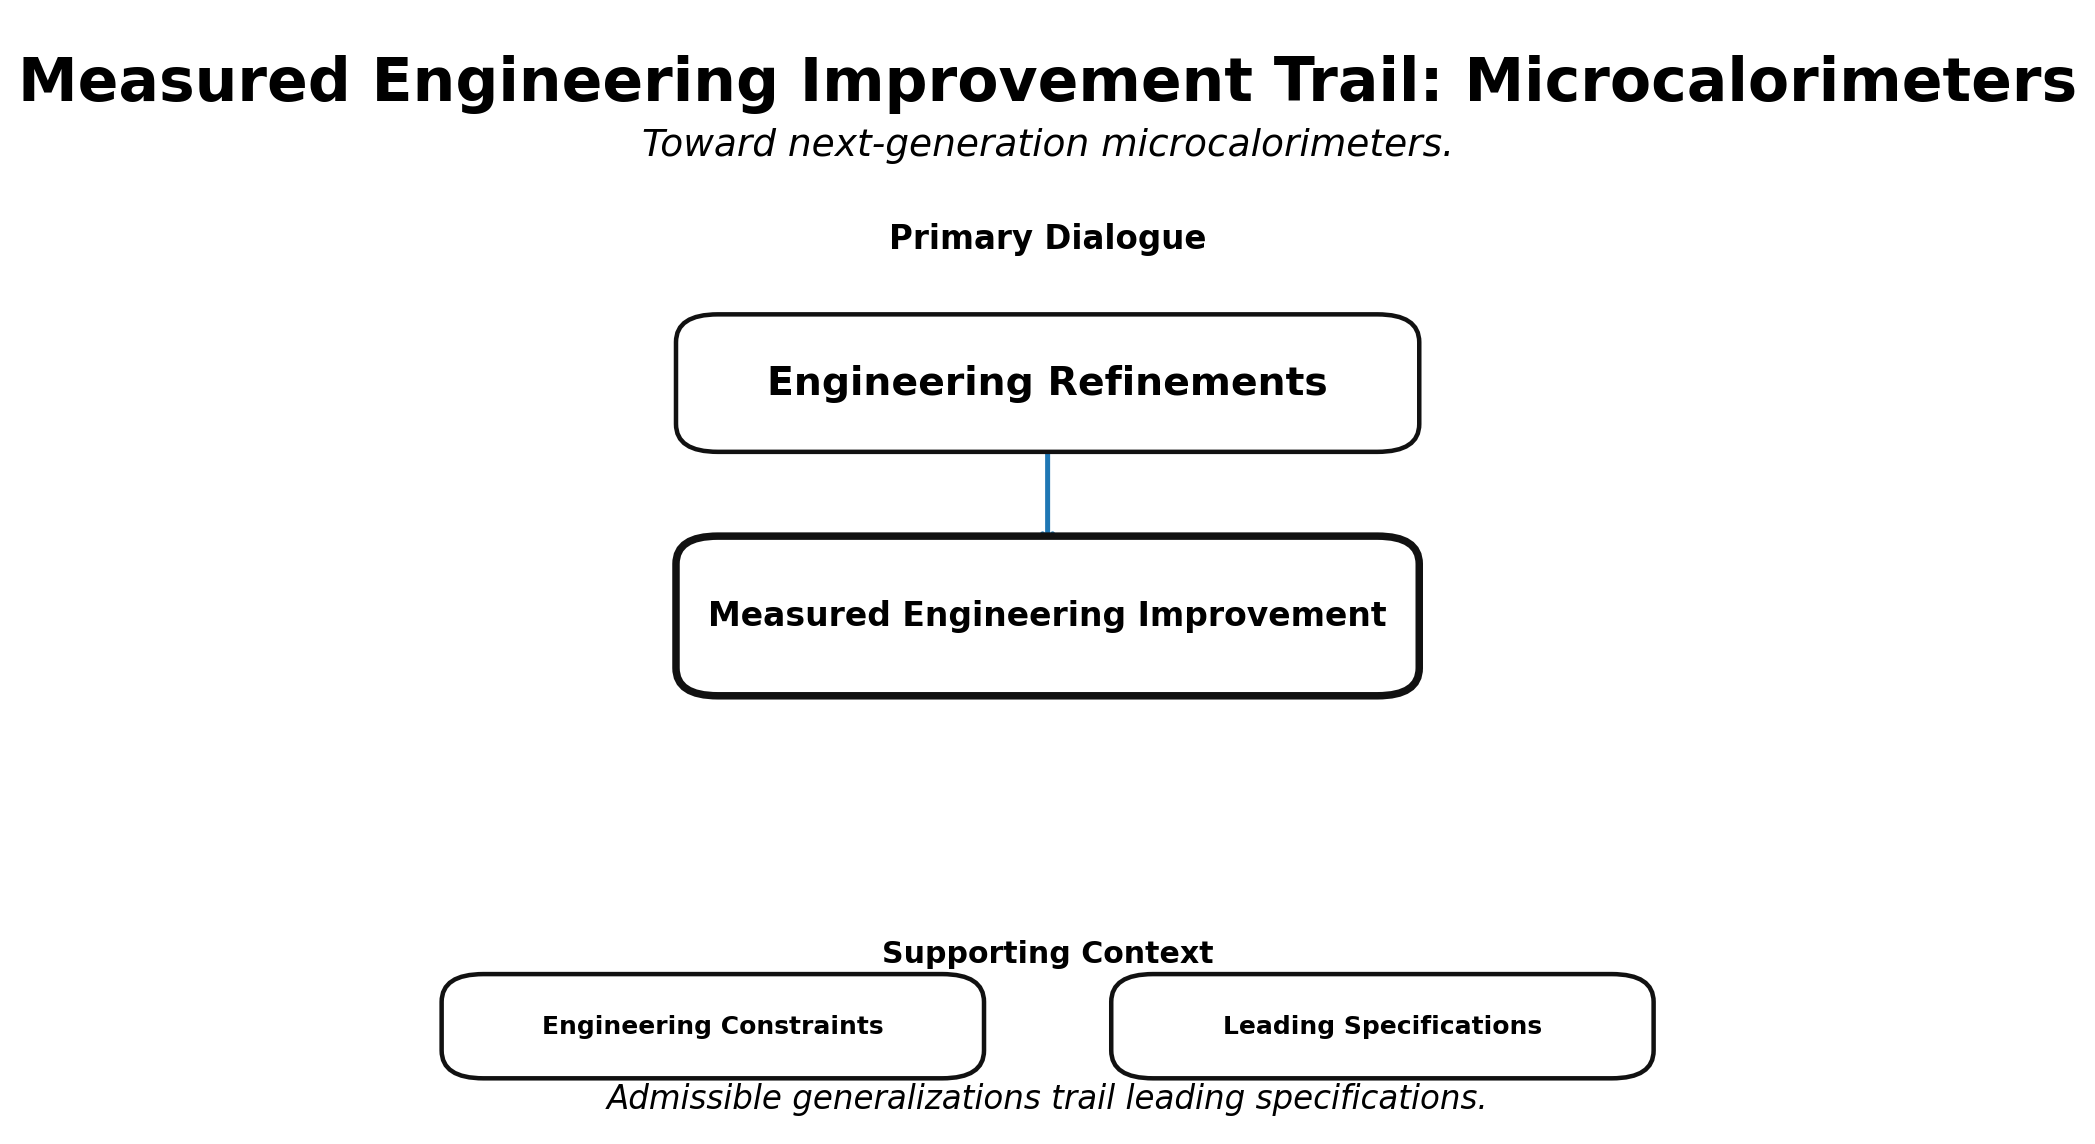

Artifact: 29_C_measured_engineering_improvement_trail.png


# Alt Text

**Measured Engineering Improvement Trail: Microcalorimeters.** Diagram showing engineering refinements leading to measured engineering improvement. Engineering Constraints and Leading Specifications appear as supporting engineering dialogue. The engineering statement is: “Engineering Refinements support Measured Engineering Improvement.” Subtitle: “Toward next-generation microcalorimeters.” Footer: “Admissible generalizations trail leading specifications.”


Artifact: 29_C_measured_engineering_improvement_trail.alt.md


In [5]:
generated_records = []

for artifact_spec in NOTEBOOK_SPEC["dialogue"]:
    png_path = bundle_directory / f"{artifact_spec.artifact_id}.png"
    alt_path = bundle_directory / f"{artifact_spec.artifact_id}.alt.md"

    renderer.render(
        build_dialogue_specification(artifact_spec),
        png_path,
    )
    alt_path.write_text(build_alt_text(artifact_spec), encoding="utf-8")

    generated_records.append(
        {
            "spec": artifact_spec,
            "png_path": png_path,
            "alt_path": alt_path,
        }
    )

    display_artifact(png_path)
    display_artifact(alt_path)

assert len(generated_records) == len(NOTEBOOK_SPEC["dialogue"])


## Generate README, Metadata, and Manifest

Bundle records are derived from the same normalized Reading Point specification.


In [6]:
artifact_count = len(NOTEBOOK_SPEC["dialogue"])
next_order = chr(ord("A") + artifact_count)

readme_path = bundle_directory / f"{NOTEBOOK_SPEC['reading_point_id'].replace('RP_', '')}_{next_order}_README.md"
metadata_path = bundle_directory / f"{NOTEBOOK_SPEC['reading_point_id'].replace('RP_', '')}_{chr(ord(next_order) + 1)}_notebook_metadata.json"
manifest_path = bundle_directory / f"{NOTEBOOK_SPEC['reading_point_id'].replace('RP_', '')}_{chr(ord(next_order) + 2)}_manifest.json"

statement_lines = "\n".join(
    f"- {statement}"
    for statement in NOTEBOOK_SPEC["engineering_statements"]
)
grammar_lines = "\n".join(
    f"- {statement}"
    for statement in NOTEBOOK_SPEC["repository_grammar"]
) or "- No additional repository grammar supplied."

dialogue_lines = "\n\n".join(
    (
        f"### {item.order}\n\n"
        f"{item.first_label}\n\n↓\n\n{item.second_label}\n\n"
        f"{item.engineering_statement}"
    )
    for item in NOTEBOOK_SPEC["dialogue"]
)

readme_text = f"""# {NOTEBOOK_SPEC["notebook_id"]}

Generated by `{TEMPLATE_ID}` v{TEMPLATE_VERSION} from `{spec_path.name}`.

## Reading Point

{NOTEBOOK_SPEC["reading_point_id"]}

## Natural Foundation

{NOTEBOOK_SPEC["natural_foundation"]}

## Engineering Objective

{NOTEBOOK_SPEC["engineering_objective"]}

## Engineering Dialogue

{dialogue_lines}

## Engineering Statements

{statement_lines}

## Forward Context

{NOTEBOOK_SPEC["forward_context"] or "To be specified."}

## Repository Grammar

{grammar_lines}

## Engineering Object

{NOTEBOOK_SPEC["engineering_object"]}

## Engineering Direction

{NOTEBOOK_SPEC["engineering_direction"]}

---

*{NOTEBOOK_SPEC["footer"]}*
"""
readme_path.write_text(readme_text, encoding="utf-8")

reading_point_record = {
    "reading_point_id": NOTEBOOK_SPEC["reading_point_id"],
    "inherited_from": NOTEBOOK_SPEC["inherited_from"],
    "natural_foundation": NOTEBOOK_SPEC["natural_foundation"],
    "engineering_objective": NOTEBOOK_SPEC["engineering_objective"],
    "engineering_statements": list(NOTEBOOK_SPEC["engineering_statements"]),
    "repository_grammar": list(NOTEBOOK_SPEC["repository_grammar"]),
    "forward_context": NOTEBOOK_SPEC["forward_context"],
    "status": NOTEBOOK_SPEC["completion_status"],
}

metadata = {
    "artifact_type": "compiled_notebook_bundle",
    "template_id": TEMPLATE_ID,
    "template_version": TEMPLATE_VERSION,
    "source_specification": str(runtime.relative_path(spec_path)),
    "notebook_id": NOTEBOOK_SPEC["notebook_id"],
    "notebook_filename": NOTEBOOK_SPEC["notebook_filename"],
    "notebook_version": NOTEBOOK_SPEC["notebook_version"],
    "repository": context.repository,
    "engineering_stage": NOTEBOOK_SPEC["engineering_stage"],
    "engineering_object": NOTEBOOK_SPEC["engineering_object"],
    "engineering_direction": NOTEBOOK_SPEC["engineering_direction"],
    "architecture": "reading-point-compiler",
    "status": NOTEBOOK_SPEC["status"],
    "reading_point": reading_point_record,
    "renderer": {
        "name": renderer.__class__.__name__,
        "module": renderer.__class__.__module__,
    },
    "runtime_environment": runtime.environment,
    "generated": date.today().isoformat(),
}
metadata_path.write_text(
    json.dumps(metadata, indent=2) + "\n",
    encoding="utf-8",
)

manifest_artifacts = []
for record in generated_records:
    item = record["spec"]
    for realization_order, path in enumerate(
        (record["png_path"], record["alt_path"]),
        start=1,
    ):
        manifest_artifacts.append(
            {
                "artifact_order": item.order,
                "artifact_id": item.artifact_id,
                "engineering_concept": item.concept,
                "engineering_statement": item.engineering_statement,
                "dialogue_status": item.status,
                "primary_dialogue": [item.first_label, item.second_label],
                "supporting_context": list(item.supporting_context),
                "realization_order": realization_order,
                "realization_type": (
                    "png" if path.suffix.lower() == ".png" else "alt_text"
                ),
                "filename": path.name,
                "size_bytes": path.stat().st_size,
                "sha256": sha256_for_path(path),
                "status": "verified",
            }
        )

for order, path in (
    (next_order, readme_path),
    (chr(ord(next_order) + 1), metadata_path),
):
    manifest_artifacts.append(
        {
            "artifact_order": order,
            "artifact_id": path.stem,
            "engineering_concept": "bundle_record",
            "filename": path.name,
            "size_bytes": path.stat().st_size,
            "sha256": sha256_for_path(path),
            "status": "verified",
        }
    )

manifest = {
    "release_filename": NOTEBOOK_SPEC["release_filename"],
    "repository": context.repository,
    "template_id": TEMPLATE_ID,
    "template_version": TEMPLATE_VERSION,
    "notebook_id": NOTEBOOK_SPEC["notebook_id"],
    "notebook_version": NOTEBOOK_SPEC["notebook_version"],
    "engineering_stage": NOTEBOOK_SPEC["engineering_stage"],
    "architecture": "reading-point-compiler",
    "status": NOTEBOOK_SPEC["status"],
    "reading_point": reading_point_record,
    "dialogue": [
        {
            "order": item.order,
            "concept": item.concept,
            "statement": item.engineering_statement,
            "status": item.status,
        }
        for item in NOTEBOOK_SPEC["dialogue"]
    ],
    "artifacts": manifest_artifacts,
}
manifest_path.write_text(
    json.dumps(manifest, indent=2) + "\n",
    encoding="utf-8",
)

for path in (readme_path, metadata_path, manifest_path):
    display_artifact(path)


NameError: name 'renderer_module' is not defined

## Verify Compiled Bundle

Verification checks identities, Reading Point content, artifact hashes, and generated filenames without notebook-specific edits.


In [ ]:
bundle_artifact_paths = [
    path
    for record in generated_records
    for path in (record["png_path"], record["alt_path"])
] + [
    readme_path,
    metadata_path,
    manifest_path,
]

assert all(
    path.exists() and path.stat().st_size > 0
    for path in bundle_artifact_paths
)

with metadata_path.open(encoding="utf-8") as handle:
    metadata_check = json.load(handle)

with manifest_path.open(encoding="utf-8") as handle:
    manifest_check = json.load(handle)

assert metadata_check["template_id"] == TEMPLATE_ID
assert metadata_check["template_version"] == TEMPLATE_VERSION
assert metadata_check["notebook_id"] == NOTEBOOK_SPEC["notebook_id"]
assert metadata_check["reading_point"]["reading_point_id"] == (
    NOTEBOOK_SPEC["reading_point_id"]
)
assert metadata_check["reading_point"]["engineering_statements"] == list(
    NOTEBOOK_SPEC["engineering_statements"]
)

assert len(manifest_check["dialogue"]) == len(
    NOTEBOOK_SPEC["dialogue"]
)
assert [
    item["order"] for item in manifest_check["dialogue"]
] == [
    item.order for item in NOTEBOOK_SPEC["dialogue"]
]

for record in manifest_check["artifacts"]:
    path = bundle_directory / record["filename"]
    assert path.exists()
    assert sha256_for_path(path) == record["sha256"]

for path in bundle_artifact_paths:
    print(f"✓ {path.name} ({path.stat().st_size} bytes)")

print("✓ YAML specification validated")
print("✓ Dialogue artifacts verified")
print("✓ README, metadata, and manifest verified")
print("✓ Artifact hashes verified")
print("✓ Compiled notebook bundle verified")


## Package and Download

The verified artifact bundle and source YAML specification are packaged together.


In [ ]:
release_directory = runtime.paths.outputs / "releases"
release_directory.mkdir(parents=True, exist_ok=True)
release_path = release_directory / NOTEBOOK_SPEC["release_filename"]

with zipfile.ZipFile(release_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in bundle_artifact_paths:
        archive.write(path, arcname=path.name)
    archive.write(spec_path, arcname=f"specifications/{spec_path.name}")

with zipfile.ZipFile(release_path) as archive:
    archived_names = archive.namelist()
    assert all(path.name in archived_names for path in bundle_artifact_paths)
    assert f"specifications/{spec_path.name}" in archived_names

print(
    f"✓ {runtime.relative_path(release_path)} "
    f"({release_path.stat().st_size} bytes)"
)

if runtime.environment == "google-colab":
    from google.colab import files
    files.download(str(release_path))
else:
    print(release_path)


## Reading Point Summary

The compiled notebook identity, engineering objective, statements, and artifacts are summarized from the YAML source.


In [ ]:
summary = {
    "notebook_id": NOTEBOOK_SPEC["notebook_id"],
    "reading_point_id": NOTEBOOK_SPEC["reading_point_id"],
    "engineering_stage": NOTEBOOK_SPEC["engineering_stage"],
    "engineering_objective": NOTEBOOK_SPEC["engineering_objective"],
    "engineering_statements": NOTEBOOK_SPEC["engineering_statements"],
    "artifact_ids": tuple(
        item.artifact_id for item in NOTEBOOK_SPEC["dialogue"]
    ),
    "release_filename": NOTEBOOK_SPEC["release_filename"],
    "status": NOTEBOOK_SPEC["status"],
}

summary


*Admissible generalizations trail leading specifications.*